In [10]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score


In [11]:
data = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML241EN-SkillsNetwork/labs/datasets/Human_Activity_Recognition_Using_Smartphones_Data.csv', sep=',')

# Display the first few rows of the dataset
print(data.shape)

(10299, 562)


In [12]:
data.shape[0]

10299

tBodyAcc-mean()-X                       float64
tBodyAcc-mean()-Y                       float64
tBodyAcc-mean()-Z                       float64
tBodyAcc-std()-X                        float64
tBodyAcc-std()-Y                        float64
                                         ...   
angle(tBodyGyroJerkMean,gravityMean)    float64
angle(X,gravityMean)                    float64
angle(Y,gravityMean)                    float64
angle(Z,gravityMean)                    float64
Activity                                 object
Length: 562, dtype: object

In [13]:
data["Activity"].value_counts(normalize=True)

Activity
LAYING                0.188756
STANDING              0.185067
SITTING               0.172541
WALKING               0.167201
WALKING_UPSTAIRS      0.149917
WALKING_DOWNSTAIRS    0.136518
Name: proportion, dtype: float64

In [14]:
#Label Encode the Activity column
le = LabelEncoder()
le.fit(data["Activity"])
data["Activity"] = le.transform(data["Activity"])
le.classes_

array(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
       'WALKING_UPSTAIRS'], dtype=object)

In [15]:
#Run KNN on complete dataset
from sklearn.model_selection import train_test_split
X = data.drop(columns=['Activity'])
y = data['Activity']
y

0        2
1        2
2        2
3        2
4        2
        ..
10294    5
10295    5
10296    5
10297    5
10298    5
Name: Activity, Length: 10299, dtype: int64

In [17]:
from sklearn.neighbors import KNeighborsClassifier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print("F1 Score:", f1_score(y_test, y_pred, average='macro'))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

F1 Score: 0.9584653829591779
Accuracy Score: 0.9559870550161812


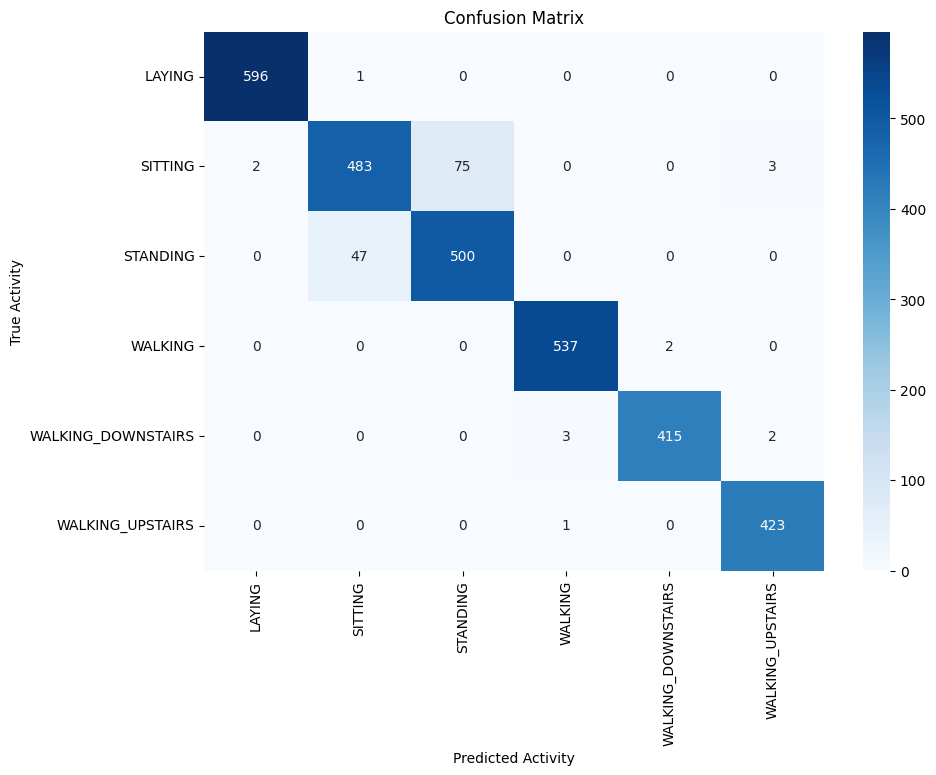

In [18]:
#Display confusion matrix
confusion = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Activity')
plt.ylabel('True Activity')
plt.title('Confusion Matrix')
plt.show()

#Finding the optimal KNN
f1 = []
for i in range(1, 51):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    f1.append(pd.Series(name=i, data=f1_score(y_test, y_pred, average='macro')))

f1_data = pd.concat(f1, axis=1).T
f1_data.rename(columns={0: 'F1 Score'}, inplace=True)


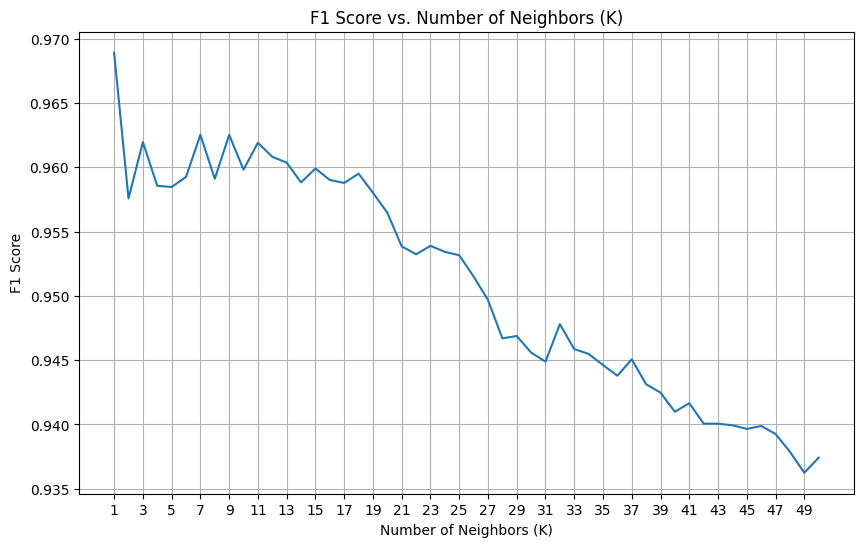

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=f1_data, x=f1_data.index, y='F1 Score', ax=ax)
ax.set_title('F1 Score vs. Number of Neighbors (K)')
ax.set_xlabel('Number of Neighbors (K)')
ax.set_ylabel('F1 Score')
plt.xticks(np.arange(1, 51, 2))
plt.grid()
plt.show()

Optimal F1 Score: 0.9625186804763226
Optimal Accuracy Score: 0.96084142394822
Optimal Recall Score:                     precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       597
           SITTING       0.93      0.87      0.90       563
          STANDING       0.88      0.93      0.91       547
           WALKING       0.99      1.00      0.99       539
WALKING_DOWNSTAIRS       1.00      0.98      0.99       420
  WALKING_UPSTAIRS       0.98      1.00      0.99       424

          accuracy                           0.96      3090
         macro avg       0.96      0.96      0.96      3090
      weighted avg       0.96      0.96      0.96      3090



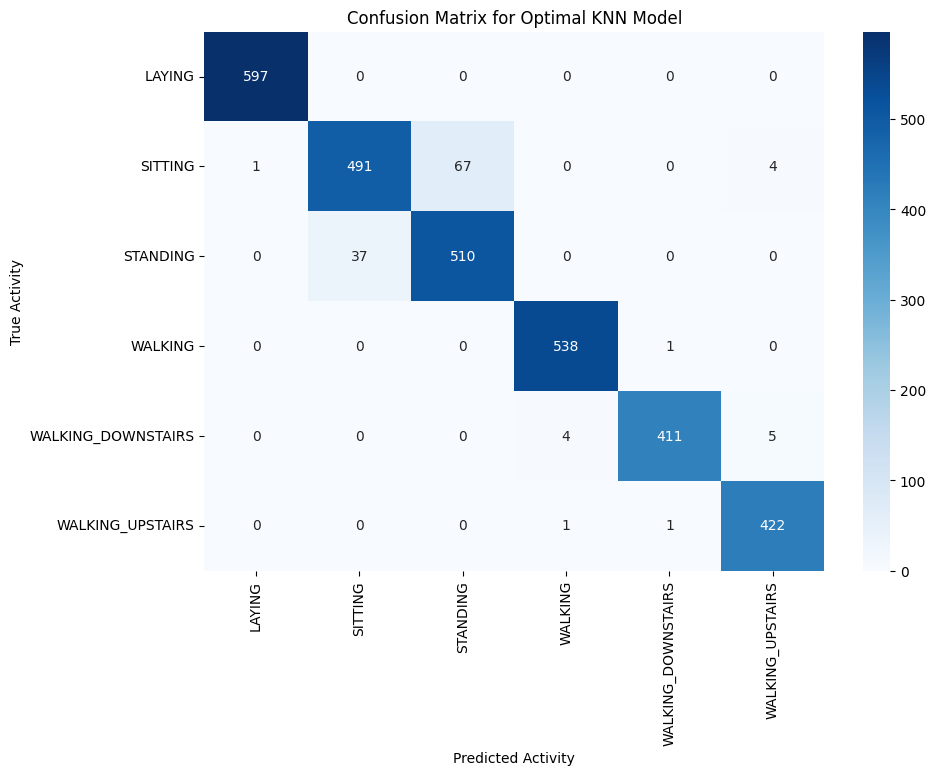

In [23]:
#Optimum model: K = 9
knn_optimal = KNeighborsClassifier(n_neighbors=9)
knn_optimal.fit(X_train, y_train)
y_pred_optimal = knn_optimal.predict(X_test)
optimal_f1_score = f1_score(y_test, y_pred_optimal, average='macro')
print("Optimal F1 Score:", f1_score(y_test, y_pred_optimal, average='macro'))
print("Optimal Accuracy Score:", accuracy_score(y_test, y_pred_optimal))
#Display confusion matrix for optimal model
confusion_optimal = confusion_matrix(y_test, y_pred_optimal)
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_optimal, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Activity')
plt.ylabel('True Activity')
plt.title('Confusion Matrix for Optimal KNN Model')
plt.show()

In [31]:
import random
# Function to generate random data for prediction
def generate_sample_subsets(data, number_of_samples=1000):
    #Minimum number of samples = 100
    #Maximum number of samples = 2000
    l = list()
    minimum_samples = 100
    maximum_samples = 2000
    for _ in range(number_of_samples):
        
        sample_size = random.randint(minimum_samples, maximum_samples)
        random_start_location = random.randint(0, data.shape[0] - sample_size)
        generated_dataframe = data.iloc[random_start_location:random_start_location + sample_size]
        a = generated_dataframe.copy()
        l.append(a)

    return l

In [39]:
random_samples = generate_sample_subsets(data, number_of_samples=100)


In [45]:
#Find the most optimal KNN model for each random sample

from sklearn.model_selection import GridSearchCV
best_neighbours = []
best_F1_scores = []
i = 0
for df in random_samples:
    params = {'n_neighbors': np.arange(3, 51)}
    knn = KNeighborsClassifier()
    grid_search = GridSearchCV(knn, params, cv=3, scoring='f1_macro', n_jobs=-1)
    X = df.drop(columns=['Activity'])
    y = df['Activity']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
    grid_search.fit(X_train, y_train)
    best_neighbours.append(grid_search.best_params_['n_neighbors'])
    best_F1_scores.append(grid_search.best_score_)
    i+=1
    if( i % 10 == 0):
        print(f"Processed {i} samples")


Processed 10 samples
Processed 20 samples


/Users/abhirajraje/Desktop/ML-Roadmap/Supervised ML Classification/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Processed 30 samples
Processed 40 samples
Processed 50 samples
Processed 60 samples
Processed 70 samples
Processed 80 samples
Processed 90 samples
Processed 100 samples


In [52]:
optimal_f1_complete_dataset = 0.9625186804763226

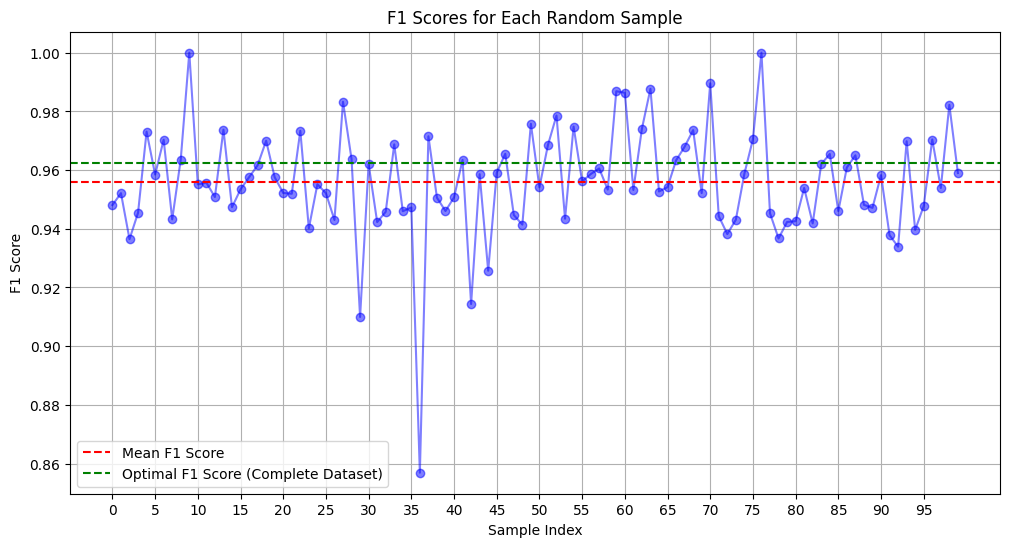

In [50]:
#Plot the F1 scores for each sample
plt.figure(figsize=(12, 6))
plt.plot(best_F1_scores, marker='o', linestyle='-', color='b', alpha = 0.5)
plt.axhline(y=np.mean(best_F1_scores), color='r', linestyle='--', label='Mean F1 Score')
plt.axhline(y=optimal_f1_complete_dataset, color='g', linestyle='--', label='Optimal F1 Score (Complete Dataset)')
plt.legend()
plt.title('F1 Scores for Each Random Sample')
plt.xlabel('Sample Index')
plt.ylabel('F1 Score')
plt.xticks(np.arange(0, len(best_F1_scores), 5))
plt.grid()
plt.show()

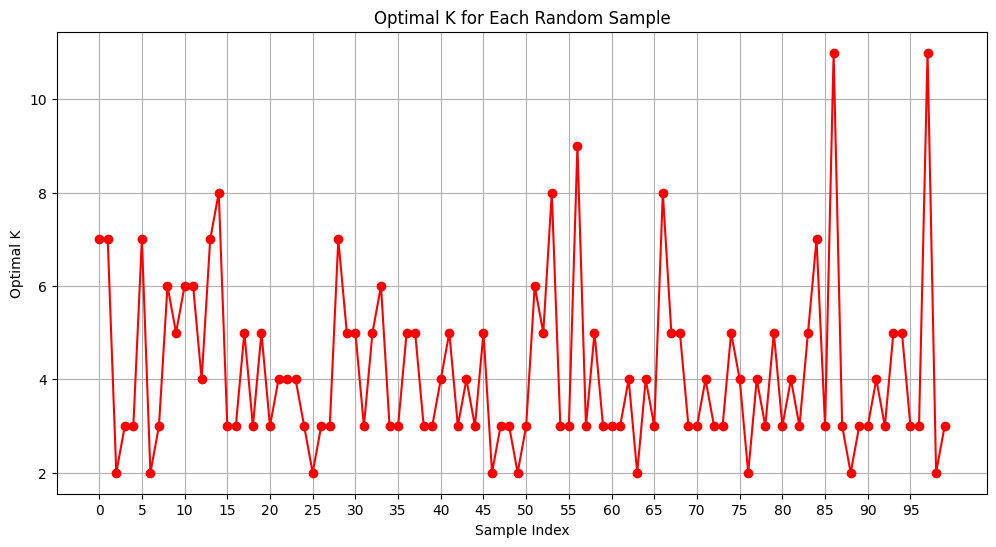

In [44]:
#Plot the optimal K for each sample
plt.figure(figsize=(12, 6))
plt.plot(best_neighbours, marker='o', linestyle='-', color='r')
plt.title('Optimal K for Each Random Sample')
plt.xlabel('Sample Index')
plt.ylabel('Optimal K')
plt.xticks(np.arange(0, len(best_neighbours), 5))
plt.grid()
plt.show()


In [55]:
#Dataframe with number of samples and corresponding best F1 score
num_samples = []
for df in random_samples:
    num_samples.append(df.shape[0])

sample_dict = {}
for i in range(len(num_samples)):
    sample_dict[num_samples[i]] = best_F1_scores[i]
sample_df = pd.DataFrame(list(sample_dict.items()), columns=['Number of Samples', 'Best F1 Score'])
sample_df.sort_values(by='Number of Samples', inplace=True)
sample_df.reset_index(inplace=True, drop=True)
sample_df.head()

,Number of Samples,Best F1 Score
0,131,0.982222
1,133,1.000000
2,149,0.983269
3,150,0.909940
4,166,0.986883


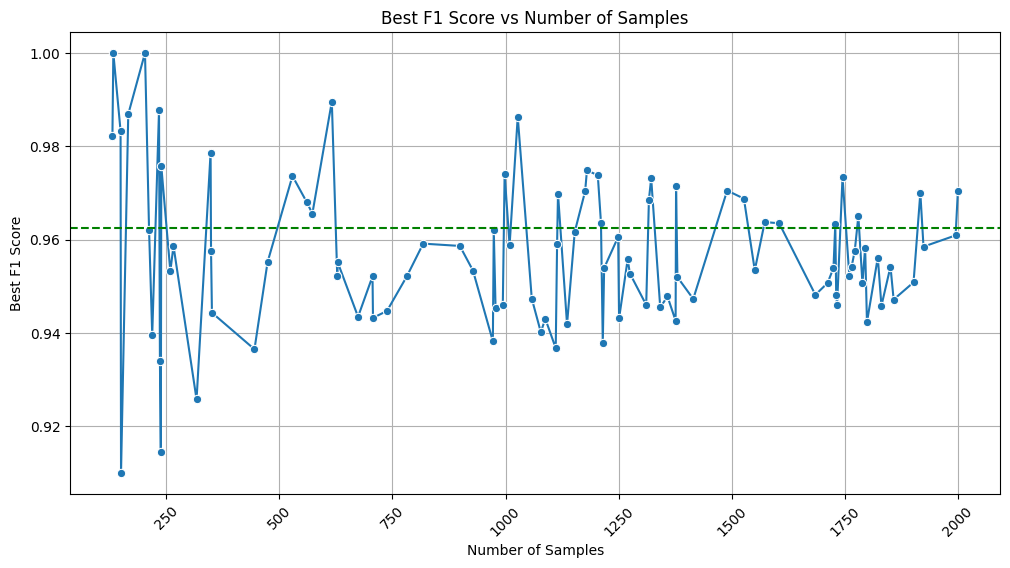

In [56]:
#Plot the best F1 score vs number of samples
plt.figure(figsize=(12, 6))
sns.lineplot(data=sample_df, x='Number of Samples', y='Best F1 Score', marker='o')
plt.axhline(y=optimal_f1_complete_dataset, color='g', linestyle='--', label='Optimal F1 Score (Complete Dataset)')
plt.title('Best F1 Score vs Number of Samples')
plt.xlabel('Number of Samples')
plt.ylabel('Best F1 Score')
plt.xticks(rotation=45)
plt.grid()
plt.show()

NameError: name 'random_samples' is not defined